## Spiral Wave Initiation

Spiral waves are a fundamental class of self-sustaining reentrant patterns that emerge in excitable media, including cardiac tissue. In the context of cardiac electrophysiology, they are closely associated with life-threatening arrhythmias such as tachycardia and fibrillation. Numerical models provide a controlled framework to study how such waves are initiated, evolve, and interact with tissue heterogeneities. In this tutorial, we demonstrate how to induce a spiral wave using the **Finitewave** framework, highlighting the key steps required to generate and visualize reentrant activity.

## Temporal block

Reentry can be initiated by introducing a temporary conduction block.
- Initially, a non-conductive region is imposed (`mesh = 2`) to stop local wave propagation.
- The wavefront propagates around this barrier, creating conditions for reentry.
- After a delay, the barrier is removed using a Command to restore conductivity.
- Proper timing allows the wave to re-enter and form a spiral pattern.

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 15400/15400 [00:01<00:00, 12957.33it/s]


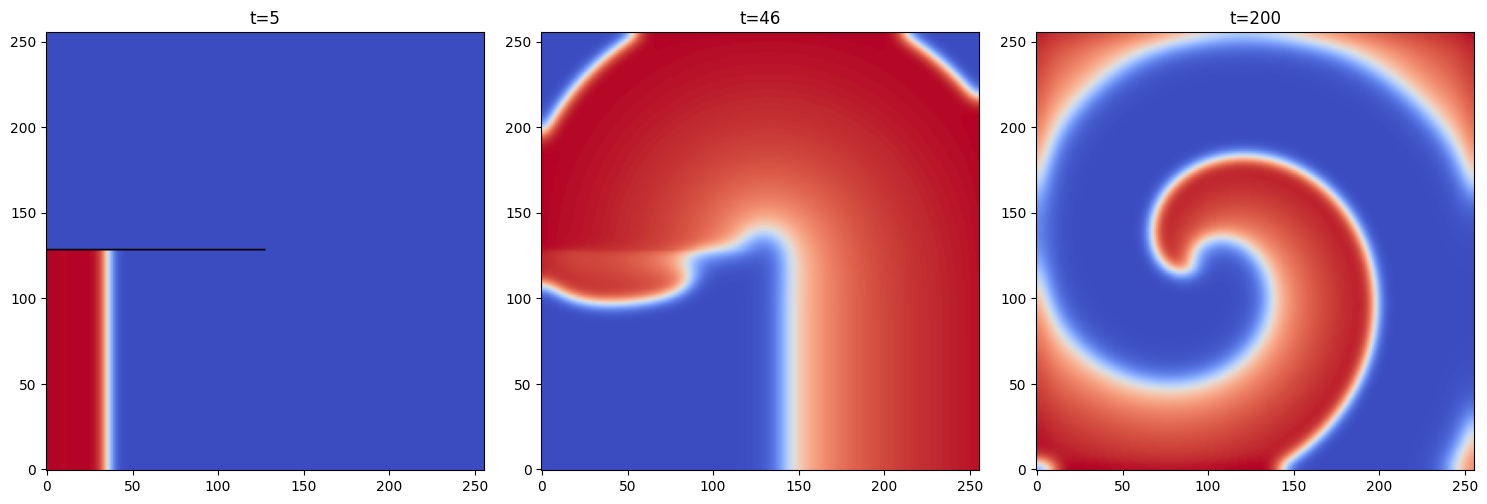

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


class CleanMesh(fw.Command):
    """
    Update the mesh of the cardiac tissue during the simulation.
    """
    def __init__(self, time):
        """
        Initialize the command with the time and the updated mesh.

        Parameters
        ----------
        time : float
            The time at which the command should be executed.
        """
        super().__init__(time)

    def execute(self, simulation):
        simulation.cardiac_tissue.clean()
        simulation.diffusion_model.update_weights()
        simulation.cardiac_model.wrap_indexes()
        simulation.solver.assemble_system()


# set up the tissue:
n = 256
t_record = [5, 46, 200]
tissue = fw.CardiacTissue([n, n], dr=0.25)
tissue.mesh[n//2, :n//2] = 2

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=0, x_max=n//2,
                                           y_min=0, y_max=5))
# set up the command sequence to update the mesh during the simulation:
command_sequence = fw.CommandSequence()
command_sequence.add_command(CleanMesh(time=40))

# set up the model:
model = fw.AlievPanfilov()

# create simulation
simulation = fw.CardiacSimulation(dt=0.01, t_max=10, backend="mlx")
# add the model, the tissue and the stim parameters to the model object:
simulation.cardiac_model = model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.command_sequence = command_sequence
simulation.initialize()

u_list = []
for t_max in t_record:
    simulation.t_max = t_max
    simulation.run(initialize=False)
    u = simulation.cardiac_model.output("u")
    u[simulation.cardiac_tissue.mesh == 2] = np.nan
    u_list.append(u)

cmap = plt.cm.coolwarm
cmap.set_bad(color='black')

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
for i, u in enumerate(u_list):
    axs[i].imshow(u, cmap=cmap, origin='lower')
    axs[i].set_title(f"t={t_record[i]}")
plt.tight_layout()
plt.show()


## Cross-field stimulation (S1–S2)

This section demonstrates how to initiate a **spiral wave** in 2D cardiac tissue 
using the classical **cross-field S1–S2 stimulation** protocol.

The protocol consists of two stimuli:
1. **S1**: a planar wave propagating from top to bottom  
2. **S2**: a transverse wave applied from left to right

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 16799/16799 [00:01<00:00, 12674.42it/s]


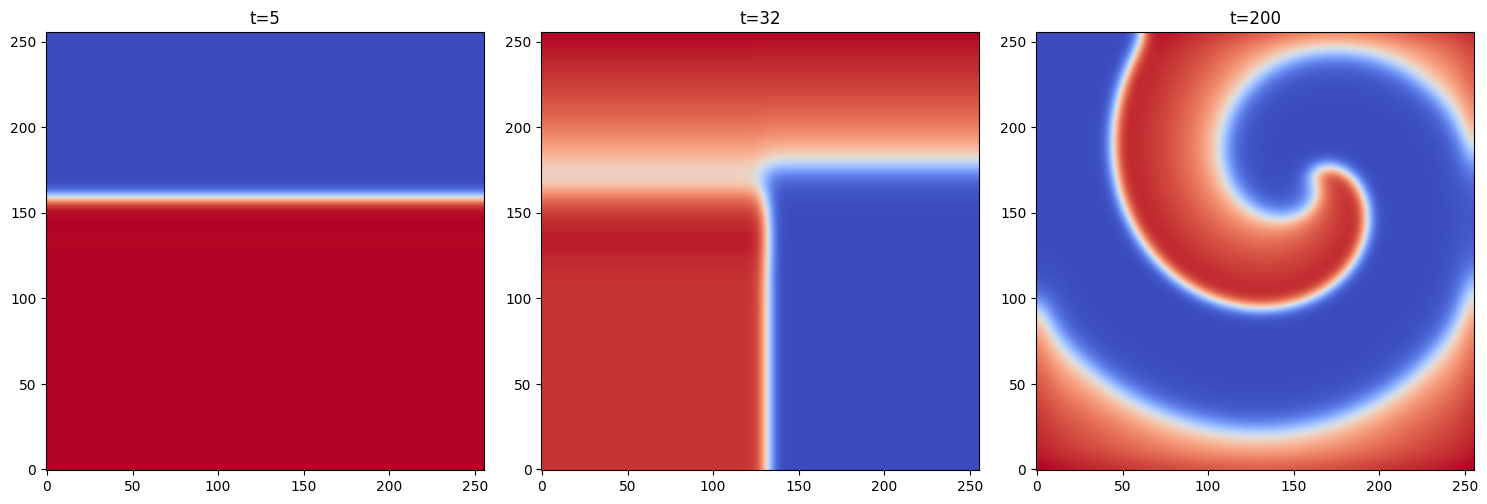

In [56]:

import matplotlib.pyplot as plt

import finitewave as fw

# set up the tissue:
n = 256
dt = 0.01   
dr = 0.25

t_record = [5, 32, 200]
tissue = fw.CardiacTissue([n, n], dr)

# set up stimulation:
stim_sequence = fw.StimS1S2Cross(tissue, s1_time=0, s2_time=31, voltage_value=1)

# create model object:
simulation = fw.CardiacSimulation(dt=dt, t_max=10, backend="mlx")
simulation.cardiac_model = fw.AlievPanfilov()
# set up numerical parameters:

# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.initialize()

u_record = []
for i, t in enumerate(t_record):
    simulation.t_max = t
    simulation.run(initialize=False)
    u = simulation.cardiac_model.output("u")
    u_record.append(u)

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
for i, u in enumerate(u_record):
    axs[i].imshow(u, cmap=cmap, origin="lower")
    axs[i].set_title(f"t={t_record[i]}")
plt.tight_layout()
plt.show()

## Time-based stimulation using threshold tracking

- Stimulation timing is determined dynamically based on tissue state.  
- A threshold tracker monitors values within the stimulation region.  
- When the signal drops below a predefined threshold (recovery phase), a stimulus is triggered.  
- This ensures stimulation occurs at the correct excitability phase.  
- Enables controlled induction of wave patterns.

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 15000/15000 [00:01<00:00, 12569.21it/s]


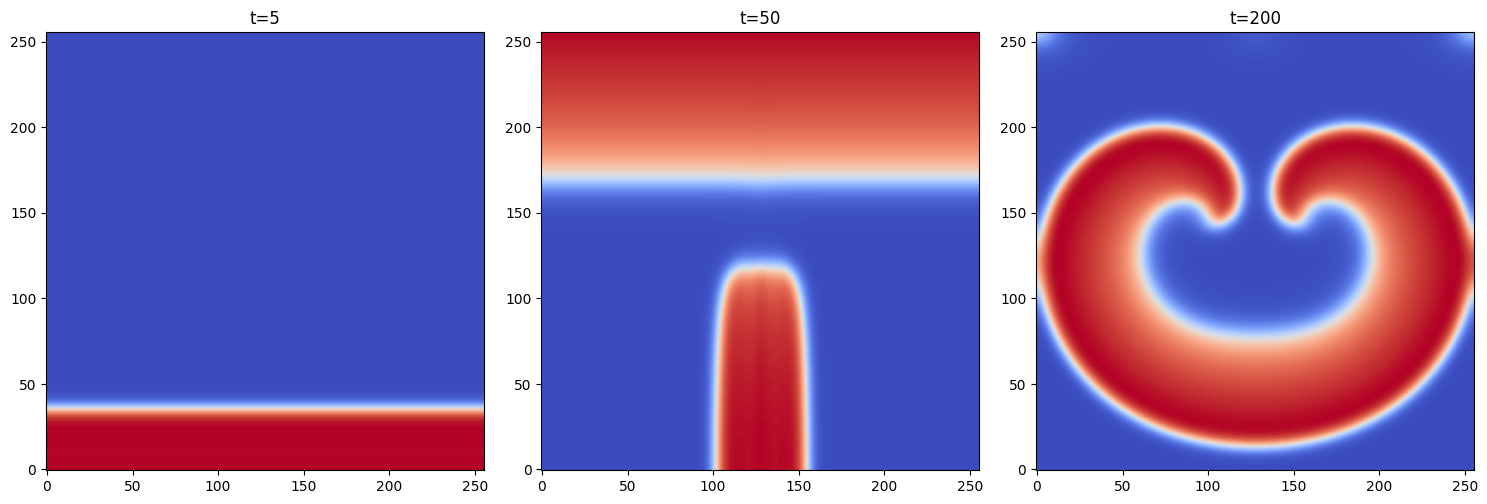

In [57]:

import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw

# set up the tissue:
n = 256
dt = 0.01   
dr = 0.25
t_record = [5, 50, 200]

tissue = fw.CardiacTissue([n, n], dr)

# set up the threshold tracker to trigger the second stimulus:
x, y = np.meshgrid(np.arange(n), np.arange(n//2 - 2, n//2 + 2))
node_inds = np.array([y.flatten(), x.flatten()]).T

threshold_tracker = fw.ThresholdTracker(node_inds=node_inds, var_name="u",
                                        threshold=0.05, start_time=0, step=10)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(threshold_tracker)

# set up stimulation:
stim_s1 = fw.StimVoltageCoord(time=0, volt_value=1, x_min=0, x_max=5, y_min=0, y_max=n)
# second stimulus will be triggered when the voltage at the specified nodes crosses the threshold
# time = 0 is just a placeholder, the actual time will be determined by the threshold tracker
stim_s2 = fw.StimVoltageCoord(time=0, volt_value=1, x_min=0, x_max=n, y_min=n//2-2, y_max=n//2+2)
stim_s2 = fw.StimAdaptiveTime(stim_s2, threshold_tracker, delay=0)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_s1)
stim_sequence.add_stim(stim_s2)

# create simulation
simulation = fw.CardiacSimulation(dt=dt, t_max=30, backend="mlx")
# add the model, the tissue and the stim parameters to the model object:
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence
simulation.initialize()

u_record = []
for t in t_record:
    simulation.t_max = t
    simulation.run(initialize=False)
    u = simulation.cardiac_model.output("u")
    u_record.append(u)

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
for i, u in enumerate(u_record):
    axs[i].imshow(u, cmap=cmap, origin="lower")
    axs[i].set_title(f"t={t_record[i]}")
plt.tight_layout()
plt.show()

## Spiral wave initialization using a phase map

- This section demonstrates direct initialization of a **spiral wave** using a **phase map**.  
- A spatial phase distribution (−π to π) is prescribed over the domain with a defined phase singularity.  
- State variables are initialized from the phase, bypassing external stimulation.  
- This produces an immediate rotating wave centered at the singularity.  
- Useful for controlled studies of spiral dynamics without transient induction protocols.

### Step 1: Obtain state variables over one period using a 1D model.  
- Simulate a single cycle and record all state variables across time.  
- This time series is later used to map phase values to model states.  

Running AlievPanfilov on [50, 1] Grid: 100%|██████████| 3000/3000 [00:00<00:00, 30288.67it/s]


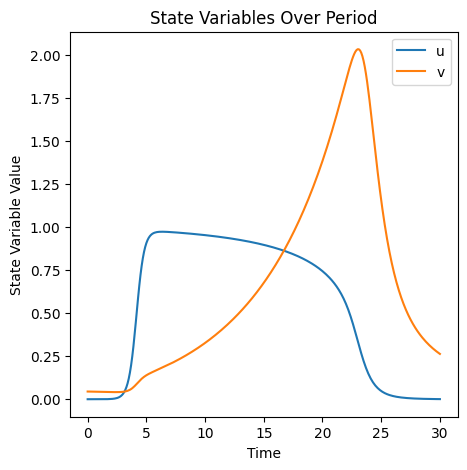

In [17]:
import finitewave as fw
import numpy as np
import matplotlib.pyplot as plt

# set up 1D tissue:
n, m = 50, 1
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=10, duration=0.1,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

# Prepace the model to ensure that the state variables are at their limit cycle.
stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=5, cycle_length=40, curr_value=1, duration=0.1)
stim_prepacing.add_stim(n_beats=5, cycle_length=30, curr_value=1, duration=0.1)
stim_prepacing.add_stim(n_beats=5, cycle_length=25, curr_value=1, duration=0.1)

model = fw.AlievPanfilov()
model.prepacing(stim_prepacing)

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, 0)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 30
simulation.cardiac_model = model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

u_list = state_tracker.output["u"]
v_list = state_tracker.output["v"]

# plot the tracked state variables over time:
plt.figure(figsize=(5, 5))
plt.plot(state_tracker.tracking_times, u_list, label="u")
plt.plot(state_tracker.tracking_times, v_list, label="v")
plt.xlabel("Time")
plt.ylabel("State Variable Value")
plt.title("State Variables Over Period")
plt.legend()
plt.show()

### Step 2: Build a phase map with a singularity at the center.  
- Define a spatial phase distribution in the range (−π, π).  
- Impose a phase singularity at the domain center to seed rotation.  
- This phase field will determine the initial condition across the tissue.

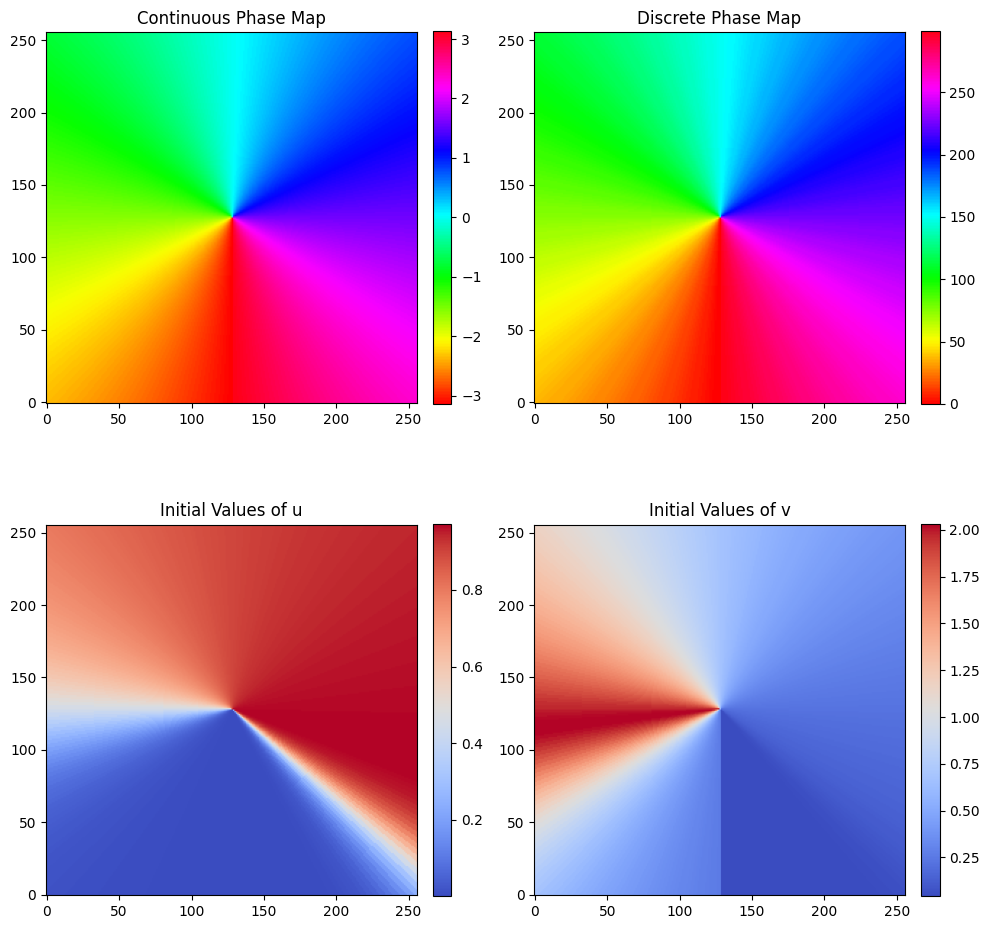

In [19]:

import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np


def build_phase_map(mesh, levels=None, phase_offset=0, clockwise=True):
    n, m = mesh.shape
    x = np.arange(n) - n // 2
    y = np.arange(m) - m // 2
    X, Y = np.meshgrid(x, y, indexing='ij')
    theta = np.arctan2(Y, X)
    theta += phase_offset
    theta = np.mod(theta + np.pi, 2 * np.pi) - np.pi  # Wrap to [-pi, pi]
    if not clockwise:
        theta = -theta

    if levels is None:
        return theta

    theta = np.digitize(theta, np.linspace(-np.pi, np.pi, levels)) - 1
    return theta.astype(int)


n = 256

phase_map = np.zeros((n, n), dtype=float)
phase_map = build_phase_map(phase_map, phase_offset=0., clockwise=True)
index_map = np.zeros((n, n), dtype=int)
index_map = build_phase_map(index_map, levels=len(u_list), phase_offset=0., clockwise=True)
u_map = u_list[::-1][index_map]
v_map = v_list[::-1][index_map]

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
im0 = axs[0, 0].imshow(phase_map, cmap='hsv', origin='lower')
axs[0, 0].set_title("Continuous Phase Map")
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)
im1 = axs[0, 1].imshow(index_map, cmap='hsv', origin='lower')
axs[0, 1].set_title("Discrete Phase Map")
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

im2 = axs[1, 0].imshow(u_map, cmap='coolwarm', origin='lower')
axs[1, 0].set_title("Initial Values of u")
fig.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)
im3 = axs[1, 1].imshow(v_map, cmap='coolwarm', origin='lower')
axs[1, 1].set_title("Initial Values of v")
fig.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Step 3: Initialize the simulation using the state-variable maps.  
- Assign mapped state variables across the 2D domain as initial conditions.  
- Run the simulation to obtain a stable rotating spiral wave.

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 10000/10000 [00:00<00:00, 11528.74it/s]


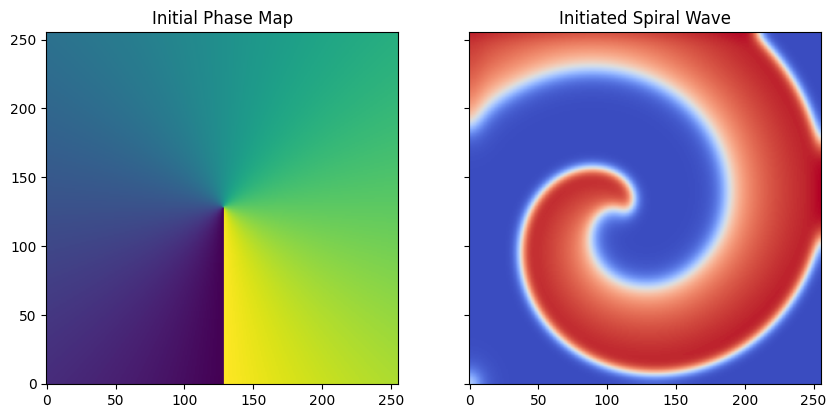

In [20]:

# set up the tissue:
tissue = fw.CardiacTissue([n, n], dr=0.25)

# prepace the model to ensure that the state variables are at their limit cycle.
model = fw.AlievPanfilov()
model.prepacing(stim_prepacing)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend='mlx')
simulation.dt = 0.01
simulation.t_max = 100
simulation.cardiac_model = model
simulation.cardiac_tissue = tissue
simulation.initialize()

# set the state variables according to the phase map:
state_vars = {'u': u_map.flatten(),
              'v': v_map.flatten()}
model.update_state_variables(state_vars)

# run the model without re-initializing to keep the state variables at their set values:
simulation.run(initialize=False)

u = model.output("u")

# show the potential map at the end of calculations:
fig, axs = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
axs[0].imshow(phase_map, cmap='viridis', origin='lower')
axs[0].set_title('Initial Phase Map')
axs[1].imshow(u, cmap='coolwarm', origin='lower')
axs[1].set_title('Initiated Spiral Wave')
plt.show()

## Rapid Pacing

- This section demonstrates **periodic (paced) stimulation** of 2D cardiac tissue.  
- The tissue contains **diffuse fibrosis**, which eventually leads to instability at high fibrosis density.  
- We use 35% randomly distributed fibrosis generated with `Diffuse2DPattern`.  
- This introduces structural heterogeneity into the tissue.  
- The heterogeneity promotes **wavefront distortion and potential breakup**.

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 16499/16499 [00:01<00:00, 13078.66it/s]


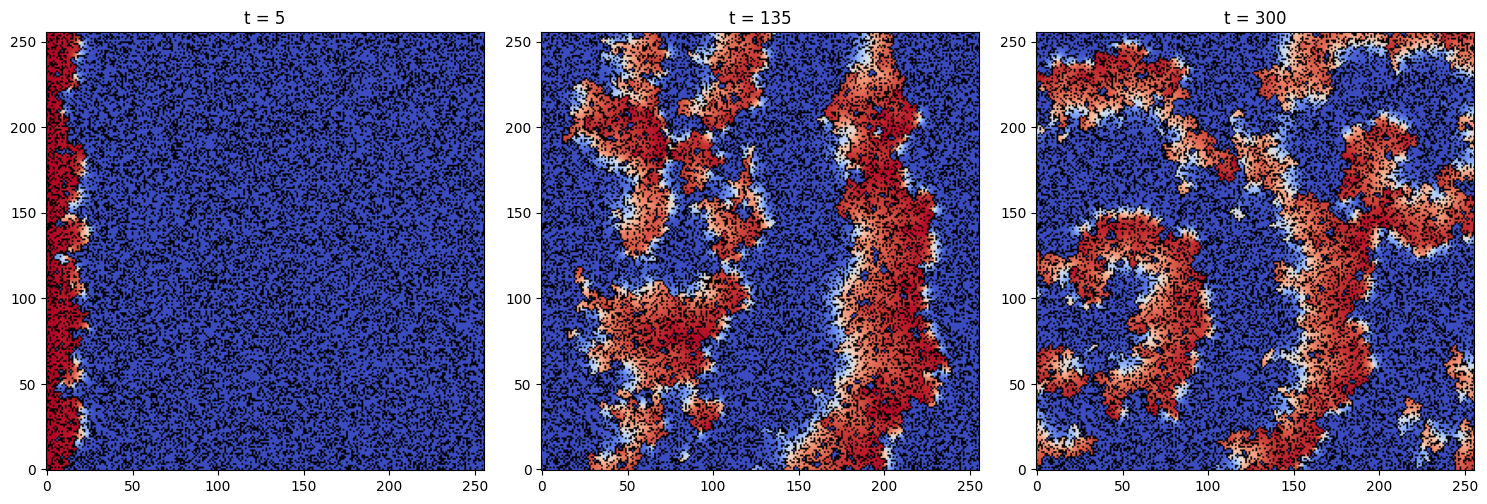

In [58]:

import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt

import finitewave as fw

# set up the tissue:
n = 256
t_record = [5, 50, 300]
tissue = fw.CardiacTissue([n, n], dr=0.25)
tissue.add_pattern(fw.Diffuse2DPattern(0.35))

# prepace model to reduce the number of beats:
stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=30, curr_value=1, duration=0.1)

model = fw.AlievPanfilov()
model.prepacing(stim_prepacing)

# set up regular stimulation with period of 27 (~270ms) model units:
stim_sequence = fw.StimSequence()
for t_stim in np.arange(0, 5 * 27, 27):
    stim_sequence.add_stim(fw.StimVoltageCoord(time=t_stim, volt_value=1,
                                               x_min=0, x_max=n, y_min=0, y_max=5))

# create model object:
simulation = fw.CardiacSimulation(dt=0.01, t_max=50, backend="mlx")
simulation.cardiac_model = model
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.initialize()
t_max = t_stim + 27
t_record[1] = t_max

u_record = []
for t in t_record:
    simulation.t_max = t
    simulation.run(initialize=False)
    u = simulation.cardiac_model.output("u")
    u[simulation.cardiac_tissue.mesh != 1] = np.nan
    u_record.append(u)

# show the wavefront fragmentation process t = 100) and the instability (t = 300) 
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
for i, u in enumerate(u_record):
    axs[i].imshow(u, cmap=cmap, origin='lower')
    axs[i].set_title(f"t = {t_record[i]}")
plt.tight_layout()
plt.show()

### S1–S2 protocol with shortened S2 coupling

- This section demonstrates spiral wave initiation with **30% diffuse fibrosis**.  
- The classical **S1–S2 stimulation protocol** is used.  
- **S1** consists of regular pacing stimuli.  
- **S2** is applied with a shorter coupling interval than the S1 pacing cycle.  
- This premature stimulation promotes conduction heterogeneity and facilitates spiral wave formation.

Running AlievPanfilov on [256, 256] Grid: 100%|██████████| 20001/20001 [00:01<00:00, 12983.98it/s]


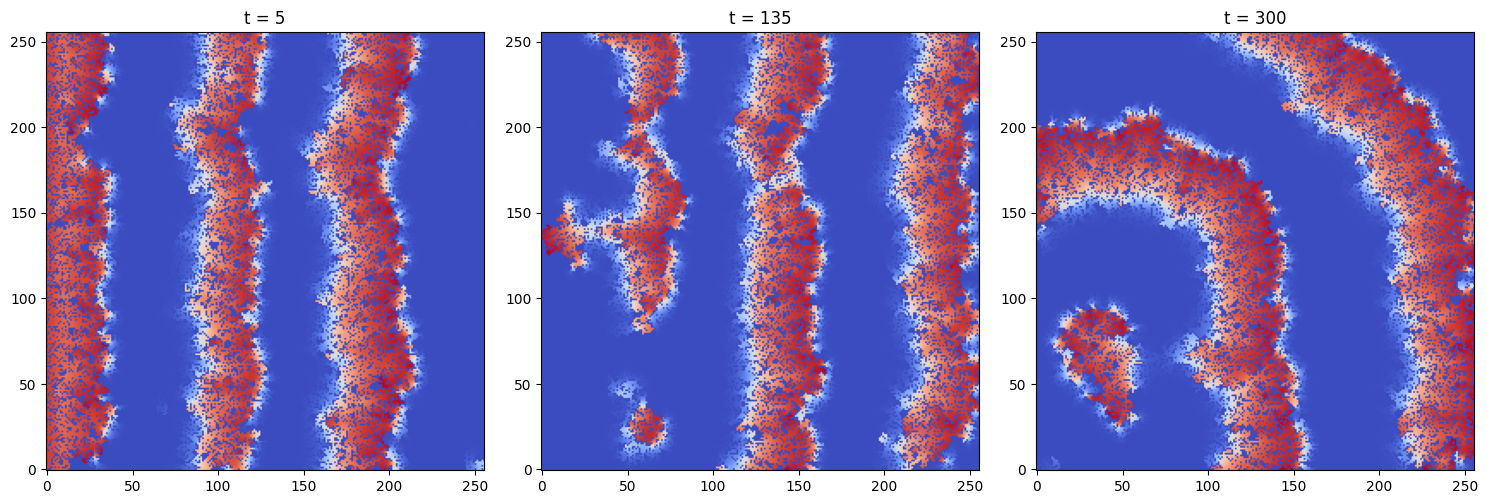

In [60]:

import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt

import finitewave as fw

# set up the tissue:
n = 256
tissue = fw.CardiacTissue([n, n], dr=0.25)
tissue.add_pattern(fw.Diffuse2DPattern(0.30))

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=30, curr_value=1, duration=0.1)

model = fw.AlievPanfilov()
model.prepacing(stim_prepacing)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
for t_stim in np.arange(0, 5 * 30, 30):
    stim_sequence.add_stim(fw.StimVoltageCoord(time=t_stim, volt_value=1,
                                               x_min=0, x_max=n, y_min=0, y_max=5))
t_stim += 22
stim_sequence.add_stim(fw.StimVoltageCoord(time=t_stim, volt_value=1,
                                           x_min=0, x_max=n, y_min=0, y_max=5))
t_max = t_stim + 30 
# create model object:
simulation = fw.CardiacSimulation(dt=0.01, t_max=100, backend="mlx")
simulation.cardiac_model = model
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence

simulation.run()
u_record = [simulation.cardiac_model.output("u")]

simulation.t_max = t_max
simulation.run(initialize=False)
u_s2 = simulation.cardiac_model.output("u")
u_record.append(u_s2)

simulation.t_max += 200
simulation.run(initialize=False)

u_final = simulation.cardiac_model.output("u")
u_record.append(u_final)

# show the wavefront fragmentation process t = 100) and the instability (t = 300) 
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
for i, u in enumerate(u_record):
    axs[i].imshow(u, cmap=cmap, origin='lower')
    axs[i].set_title(f"t = {t_record[i]}")
plt.tight_layout()
plt.show()